# Stage 3 Ablation — Run & Visualize

Runs the SGPA Stage 3 spectral refinement ablation experiment and generates figures.
Outputs saved to `experiments/interspeech/outputs/stage3_ablation/`.

In [5]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

In [7]:
from pathlib import Path

from src.stage3 import run_stage3_ablation, plot_stage3_ablation

OUTPUT_DIR: Path = Path("outputs/stage3_ablation")
FIGURES_DIR: Path = Path("figures")

DATASET_CONFIG: str = "single_sentence__voice_bench"
AUDIO_COLUMNS: list[str] = ["audio__male", "audio__female"]
MAX_SAMPLES: int = 1000

## Run experiment

Runs the ablation for all audio columns. Saves consolidated outputs:
- `samples.csv` — per-sample metrics
- `boundaries.csv` — per-boundary detail
- `summary.json` — statistics + failures

In [8]:
summary = run_stage3_ablation(
    dataset_config=DATASET_CONFIG,
    audio_columns=AUDIO_COLUMNS,
    max_samples=MAX_SAMPLES,
    output_dir=OUTPUT_DIR,
)

print(
    f"Completed: {summary['total_completed']} samples, {summary['total_failed']} failures"
)
if "combined" in summary:
    c = summary["combined"]
    print(
        f"Mean reduction: {c['mean_percent_reduction']:.1f}%, p={c['paired_p_value']:.2e}, d={c['cohen_dz']:.3f}"
    )

Loading weights:   0%|          | 0/404 [00:00<?, ?it/s]

stage3 ablation (audio__male):   0%|          | 0/854 [00:00<?, ?it/s]

stage3 ablation (audio__female):   0%|          | 0/854 [00:00<?, ?it/s]

Completed: 1708 samples, 0 failures
Mean reduction: 43.5%, p=1.56e-308, d=1.133


## Visualize results

Saved: figures/stage3_ablation.png


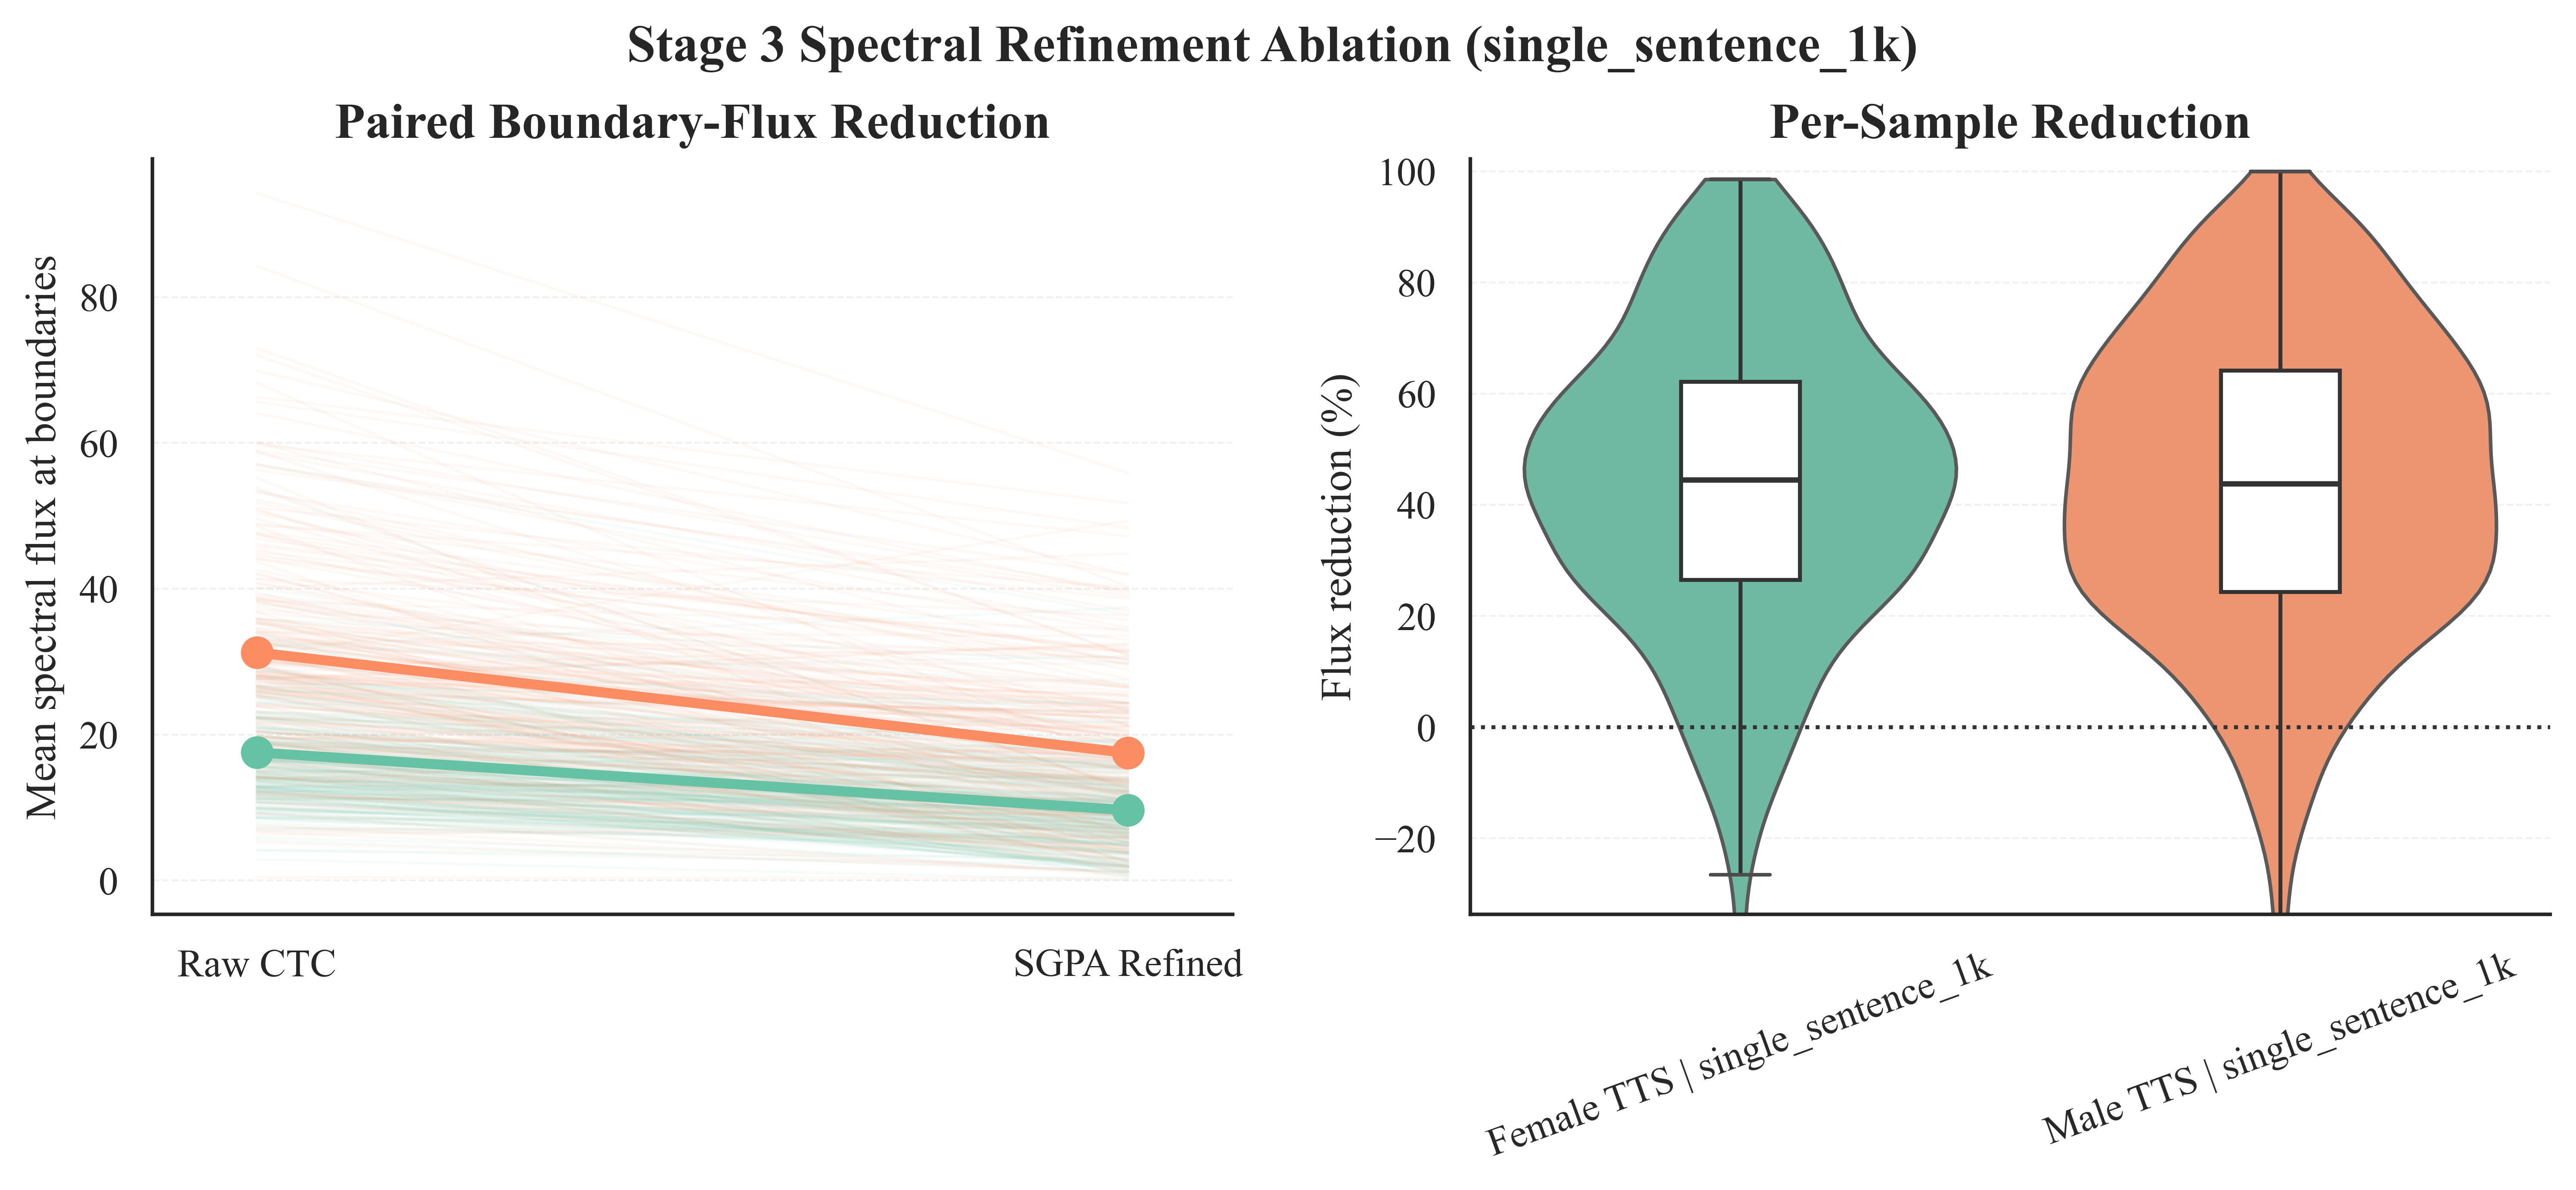

In [9]:
import matplotlib.pyplot as plt

fig = plot_stage3_ablation(
    input_dir=OUTPUT_DIR,
    output_base=FIGURES_DIR / "stage3_ablation",
    dataset_config=DATASET_CONFIG,
    summary_path=OUTPUT_DIR / "summary.json",
)
print(f"Saved: {FIGURES_DIR / 'stage3_ablation.png'}")
plt.show()